# ЦФА vs Облигации: Сравнительный анализ

**Курс:** Блокчейн. Финансовые технологии и криптоэкономика  
**Задание:** Сравнить доходность ЦФА с облигациями эмитента на первичном рынке

---

## 📋 Цели анализа:

1. Сравнить доходность ЦФА и облигаций одного эмитента
2. Объяснить наблюдаемый спред
3. Оценить риски и доходность с учетом ликвидности
4. Дать инвестиционные рекомендации

## 📦 1. Импорт библиотек и настройка

In [36]:
# Импорт стандартных библиотек
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка отображения графиков в ноутбуке
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Добавление src в path
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), 'src'))

# Импорт модулей проекта
from src.config import DFA_PARAMS, BONDS_FILTER, ANALYSIS_CONFIG, VIZ_CONFIG
from src.dfa_analyzer import DFAAnalyzer
from src.bonds_analyzer import BondsAnalyzer
from src.comparator import DFAvsBondsComparator
from src.data_fetcher import BondsDataFetcher, create_sample_bonds_data

print("✓ Все библиотеки успешно импортированы")
print(f"✓ Путь к src добавлен")
print(f"✓ Дата анализа: {datetime.now().strftime('%Y-%m-%d')}")
print(f"✓ MOEX API: готов к работе")


✓ Все библиотеки успешно импортированы
✓ Путь к src добавлен
✓ Дата анализа: 2026-04-28
✓ MOEX API: готов к работе


## 📡 1.1. Источники данных

Этот ноутбук поддерживает **два режима работы**:

### ✅ **Режим 1: MOEX API (реальные данные)**
- Автоматическое подключение к Московской бирже
- Поиск сопоставимых облигаций по эмитенту ЦФА
- Актуальные рыночные данные и доходности

**Требования:**
- Доступ к интернету
- Работающий MOEX API

### ⚠️ **Режим 2: Sample данные (тестовые)**
- Используется автоматически при недоступности API
- 4 тестовые облигации для демонстрации
- Гарантирует работу ноутбука офлайн

---

**💡 В ячейке 5 ноутбук попытается:**
1. Подключиться к MOEX API
2. Найти облигации эмитента ЦФА
3. При ошибке — автоматически переключится на sample данные

**Для продакшена:** настройте параметры соединения в `src/config.py`


## 📊 2. Параметры ЦФА для анализа

In [37]:
# Вывод параметров ЦФА
print("=" * 70)
print("ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)")
print("=" * 70)

print(f"\n📌 Идентификатор: {DFA_PARAMS['id']}")
print(f"🏢 Эмитент: {DFA_PARAMS['issuer']}")
print(f"🌐 Сайт: {DFA_PARAMS['website']}")

print(f"\n💰 Финансовые параметры:")
print(f"   • Номинал: {DFA_PARAMS['face_value']:,.2f} ₽")
print(f"   • Цена размещения: {DFA_PARAMS['placement_price']:,.2f} ₽")
print(f"   • Доходность: {DFA_PARAMS['yield_rate']}% годовых")
print(f"   • Тип купона: {DFA_PARAMS['coupon_type']}")
print(f"   • Периодичность: {DFA_PARAMS['coupon_frequency']}")

print(f"\n📅 Сроки:")
print(f"   • Размещение: {DFA_PARAMS['placement_start']} - {DFA_PARAMS['placement_end']}")
print(f"   • Погашение: {DFA_PARAMS['maturity_date']}")

print(f"\n📈 Объем выпуска:")
print(f"   • Общий объем: {DFA_PARAMS['issue_volume']:,.0f} ₽")
print(f"   • Мин. инвестиция: {DFA_PARAMS['min_investment']:,.0f} ₽")
print(f"   • Инвесторов: {DFA_PARAMS['investors_count']}")

print(f"\n⚠️ Обеспечение: {DFA_PARAMS['collateral']}")
print(f"🎯 Цель: {DFA_PARAMS['purpose']}")
print("\n" + "=" * 70)

ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)

📌 Идентификатор: A1202FB5
🏢 Эмитент: ООО 'ЦЕНТР НЕДВИЖИМОСТИ 'МАЯК'
🌐 Сайт: https://new.ural-mayak.ru

💰 Финансовые параметры:
   • Номинал: 1,000.00 ₽
   • Цена размещения: 1,000.00 ₽
   • Доходность: 17.0% годовых
   • Тип купона: fixed
   • Периодичность: quarterly

📅 Сроки:
   • Размещение: 2026-04-14 - 2026-04-30
   • Погашение: 2027-05-03

📈 Объем выпуска:
   • Общий объем: 50,000,000 ₽
   • Мин. инвестиция: 1,000 ₽
   • Инвесторов: 73

⚠️ Обеспечение: без обеспечения
🎯 Цель: пополнение оборотных средств



## 🔍 3. Анализ ЦФА

In [38]:
# Инициализация анализатора ЦФА
dfa = DFAAnalyzer()

# Получение сводки анализа
dfa_summary = dfa.get_dfa_summary()

print("\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА")
print("-" * 50)

# Временные параметры
time_metrics = dfa_summary['time_metrics']
print(f"\n⏰ Временные параметры:")
print(f"   Срок обращения: {time_metrics['years_to_maturity']:.2f} лет")
print(f"   Дней до погашения: {time_metrics['days_to_maturity']}")

# Показатели доходности
yield_metrics = dfa_summary['yield_metrics']
print(f"\n💵 Доходность:")
print(f"   Номинальная: {yield_metrics['nominal_yield_pct']:.2f}%")
print(f"   После налога: {yield_metrics['after_tax_yield_pct']:.2f}%")
print(f"   С учетом ликвидности: {yield_metrics['liquidity_adjusted_yield_pct']:.2f}%")

# Показатели возврата
return_metrics = dfa_summary['return_metrics']
print(f"\n📈 Показатели возврата:")
print(f"   Купонный доход: {return_metrics['total_coupon']:,.2f} ₽")
print(f"   Общий доход: {return_metrics['total_return_pct']:.2f}%")
print(f"   Годовая доходность: {return_metrics['annualized_return']:.2f}%")

# Рисковые метрики
risk_metrics = dfa_summary['risk_metrics']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_metrics['risk_premium']:.2f}%")
print(f"   Коэффициент Шарпа: {risk_metrics['sharpe_ratio']:.3f}")
print(f"   Бета-коэффициент: {risk_metrics['beta']:.2f}")


📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА
--------------------------------------------------

⏰ Временные параметры:
   Срок обращения: 1.05 лет
   Дней до погашения: 384

💵 Доходность:
   Номинальная: 17.00%
   После налога: 14.79%
   С учетом ликвидности: 17.00%

📈 Показатели возврата:
   Купонный доход: 170.00 ₽
   Общий доход: 17.00%
   Годовая доходность: 16.17%

⚠️ Рисковые метрики:
   Премия за риск: 5.00%
   Коэффициент Шарпа: 0.333
   Бета-коэффициент: 1.20


## 💳 4. График купонных платежей ЦФА

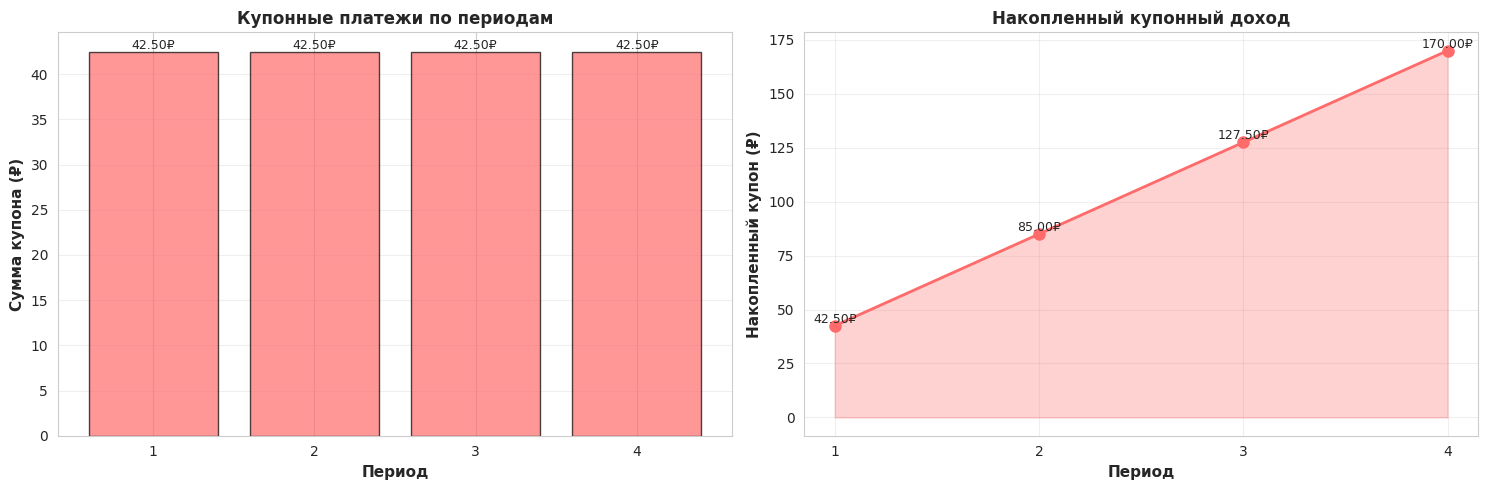


📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:
 period payment_date  days_from_placement  coupon_amount  cumulative_coupon
      1   2026-07-19                   96           42.5               42.5
      2   2026-10-23                  192           42.5               85.0
      3   2027-01-27                  288           42.5              127.5
      4   2027-05-03                  384           42.5              170.0


In [39]:
# Получение графика купонных платежей
coupon_schedule = dfa.calculate_coupon_payments()

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Купонные платежи
ax1.bar(range(1, len(coupon_schedule)+1), 
        coupon_schedule['coupon_amount'], 
        color='#FF6B6B', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Период', fontsize=11, fontweight='bold')
ax1.set_ylabel('Сумма купона (₽)', fontsize=11, fontweight='bold')
ax1.set_title('Купонные платежи по периодам', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений на бары
for i, coupon in enumerate(coupon_schedule['coupon_amount']):
    ax1.text(i+1, coupon, f'{coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

# График 2: Накопленный доход
ax2.plot(range(1, len(coupon_schedule)+1), 
         coupon_schedule['cumulative_coupon'], 
         marker='o', linewidth=2, markersize=8, color='#FF6B6B')
ax2.fill_between(range(1, len(coupon_schedule)+1), 
                  coupon_schedule['cumulative_coupon'], 
                  alpha=0.3, color='#FF6B6B')
ax2.set_xlabel('Период', fontsize=11, fontweight='bold')
ax2.set_ylabel('Накопленный купон (₽)', fontsize=11, fontweight='bold')
ax2.set_title('Накопленный купонный доход', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений
for i, cum_coupon in enumerate(coupon_schedule['cumulative_coupon']):
    ax2.text(i+1, cum_coupon, f'{cum_coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Таблица с графиком платежей
print("\n📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:")
print(coupon_schedule.to_string(index=False))

## 🏦 5. Подбор сопоставимых облигаций

In [40]:
# Получение данных по облигациям через MOEX API
print("\n🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:")
print("-" * 50)
print(f"Срок погашения: {BONDS_FILTER['maturity_min_months']}-{BONDS_FILTER['maturity_max_months']} месяцев")
print(f"Период размещения: {BONDS_FILTER['placement_month_min']} - {BONDS_FILTER['placement_month_max']}")
print(f"Мин. кредитный рейтинг: {BONDS_FILTER['min_credit_rating']}")
print(f"Объем выпуска: {BONDS_FILTER['min_issue_volume']:,.0f} - {BONDS_FILTER['max_issue_volume']:,.0f} ₽")

# Попытка получить реальные данные через MOEX API
print("\n📡 Подключение к MOEX API...")
fetcher = BondsDataFetcher()

try:
    # Поиск облигаций по эмитенту ЦФА
    issuer_name = DFA_PARAMS['issuer'].split("'")[1] if "'" in DFA_PARAMS['issuer'] else DFA_PARAMS['issuer']
    print(f"🔍 Поиск облигаций эмитента: {issuer_name}")
    
    # Поиск сопоставимых облигаций с ФИЛЬТРАЦИЕЙ
    bonds_data = fetcher.find_comparable_bonds(
        target_maturity_months=int((BONDS_FILTER['maturity_min_months'] + BONDS_FILTER['maturity_max_months']) / 2),
        placement_date=DFA_PARAMS['placement_start'][:7],  # YYYY-MM формат
        max_results=10,
        # НОВОЕ: фильтр по объёму выпуска
        min_volume=BONDS_FILTER.get('min_issue_volume', 10_000_000)
    )
    
    if bonds_data.empty:
        raise Exception("Не удалось найти облигации через API")
    
    # ===== НОВОЕ: обогащение реальной YTM =====
    print("\n📊 Получение реальной доходности (YTM) через MOEX API...")
    bonds_data = fetcher.enrich_with_ytm(bonds_data, boardid="TQCB")
    print(f"✅ YTM обновлена для {len(bonds_data)} облигаций")
    # =========================================
    
    print(f"✅ Успешно получено данных через MOEX API: {len(bonds_data)} облигаций")
    use_api = True
    
except Exception as e:
    print(f"⚠️ Ошибка MOEX API: {e}")
    print("🔄 Использование sample данных для демонстрации")
    print("💡 Для продакшена: настройте интеграцию с MOEX API")
    
    # Fallback на sample данные
    bonds_data = create_sample_bonds_data()
    use_api = False

print(f"\n✓ Найдено сопоставимых облигаций: {len(bonds_data)}")
if use_api:
    print("✓ Источник данных: MOEX API (реальные данные)")
else:
    print("⚠️ Источник данных: Sample (тестовые данные)")

# Отображение таблицы облигаций
print("\n📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:")
print("=" * 100)

# Проверка наличия нужных колонок
required_cols = ['secid', 'name', 'coupon_rate', 'ytm_primary', 'maturity_date', 'volume', 'credit_rating']
display_cols = [col for col in required_cols if col in bonds_data.columns]

if 'ytm_primary' not in bonds_data.columns and 'coupon_rate' in bonds_data.columns:
    # Если YTM отсутствует, используем coupon_rate как приближение
    bonds_data['ytm_primary'] = bonds_data['coupon_rate']
    display_cols = required_cols

print(bonds_data[display_cols].to_string(index=False))
print("=" * 100)



🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:
--------------------------------------------------
Срок погашения: 10-14 месяцев
Период размещения: 2026-03 - 2026-05
Мин. кредитный рейтинг: B
Объем выпуска: 10,000,000 - 500,000,000 ₽

📡 Подключение к MOEX API...
🔍 Поиск облигаций эмитента: ЦЕНТР НЕДВИЖИМОСТИ 


📊 MOEX API: получено 3000 облигаций (TQCB)
✅ После фильтра по сроку погашения: 221 облигаций
✅ После фильтра по объёму (≥10,000,000 ₽): 53 облигаций
📈 YTM получена для 10 облигаций из API
✅ Итого: 9 сопоставимых облигаций

📊 Получение реальной доходности (YTM) через MOEX API...
  OK RU000A0JXN21: YTM = 14.58%
  OK RU000A0JXPN8: YTM = 14.44%
  OK RU000A0JXQK2: YTM = 13.03%
  OK RU000A0JXS83: YTM = 14.46%
  OK RU000A0JXT58: YTM = 16.91%
  OK RU000A1009L8: YTM = 12.79%
  OK RU000A101M04: YTM = 14.37%
  OK RU000A101QN1: YTM = 14.41%
  OK RU000A101TB0: YTM = 14.67%
✅ YTM обновлена для 9 облигаций
✅ Успешно получено данных через MOEX API: 9 облигаций

✓ Найдено сопоставимых облигаций: 9
✓ Источник данных: MOEX API (реальные данные)

📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:
       secid       name  coupon_rate  ytm_primary maturity_date   volume credit_rating
RU000A0JXN21 СистемБ1P6            0        14.58    2027-03-26 15000000             B
RU000A0JXPN8 Ростел1P2R            0        14.44    202

## 📈 6. Анализ облигаций

In [41]:
# Инициализация анализатора облигаций
bonds_analyzer = BondsAnalyzer(bonds_data)
if use_api and bonds_data['ytm_primary'].std() < 0.01:
    print("YTM не обновлена, пробуем получить через API повторно...")
    try:
        bonds_data = fetcher.enrich_with_ytm(bonds_data)
        bonds_analyzer = BondsAnalyzer(bonds_data)
    except Exception as e:
        print(f"Не удалось обновить YTM: {e}")

bonds_analysis = bonds_analyzer.analyze_all_bonds()
bonds_summary = bonds_analyzer.get_summary_statistics(bonds_analysis)

print("\n📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ")
print("-" * 50)

# Доходность
yield_stats = bonds_summary['yield_stats']
print(f"\n💵 Доходность (YTM):")
print(f"   Средняя: {yield_stats['mean_ytm']:.2f}%")
print(f"   Медиана: {yield_stats['median_ytm']:.2f}%")
print(f"   Стд. отклонение: {yield_stats['std_ytm']:.2f}%")
print(f"   Диапазон: {yield_stats['min_ytm']:.2f}% - {yield_stats['max_ytm']:.2f}%")

# После налога
after_tax_stats = bonds_summary['after_tax_stats']
print(f"\n💰 После налога:")
print(f"   Средняя: {after_tax_stats['mean_after_tax']:.2f}%")
print(f"   Медиана: {after_tax_stats['median_after_tax']:.2f}%")

# Рисковые метрики
risk_stats = bonds_summary['risk_stats']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_stats['mean_risk_premium']:.2f}%")
print(f"   Средний Sharpe: {risk_stats['mean_sharpe']:.3f}")

# Объем
volume_stats = bonds_summary['volume_stats']
print(f"\n📊 Объем выпусков:")
print(f"   Общий: {volume_stats['total_volume']:,.0f} ₽")
print(f"   Средний: {volume_stats['mean_volume']:,.0f} ₽")


📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ
--------------------------------------------------

💵 Доходность (YTM):
   Средняя: 14.41%
   Медиана: 14.44%
   Стд. отклонение: 1.17%
   Диапазон: 12.79% - 16.91%

💰 После налога:
   Средняя: 0.00%
   Медиана: 0.00%

⚠️ Рисковые метрики:
   Премия за риск: 2.41%
   Средний Sharpe: 0.201

📊 Объем выпусков:
   Общий: 145,000,000 ₽
   Средний: 16,111,111 ₽


## 📊 7. Детальный анализ облигаций

In [42]:
# Создание красивой таблицы с анализом
display_cols = ['secid', 'coupon_rate', 'ytm_primary', 'after_tax_yield', 
               'liquidity_score', 'sharpe_ratio', 'credit_rating']

analysis_display = bonds_analysis[display_cols].copy()
analysis_display.columns = ['Облигация', 'Купон %', 'YTM %', 'После налога %', 
                             'Ликвидность', 'Sharpe', 'Рейтинг']

print("\n📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:")
print("=" * 100)
print(analysis_display.to_string(index=False))
print("=" * 100)


📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:
   Облигация  Купон %  YTM %  После налога %  Ликвидность   Sharpe Рейтинг
RU000A0JXN21        0  14.58             0.0          0.7 0.215000       B
RU000A0JXPN8        0  14.44             0.0          0.7 0.203333       B
RU000A0JXQK2        0  13.03             0.0          0.7 0.085833       B
RU000A0JXS83        0  14.46             0.0          0.7 0.205000       B
RU000A0JXT58        0  16.91             0.0          0.7 0.409167       B
RU000A1009L8        0  12.79             0.0          0.7 0.065833       B
RU000A101M04        0  14.37             0.0          0.7 0.197500       B
RU000A101QN1        0  14.41             0.0          0.7 0.200833       B
RU000A101TB0        0  14.67             0.0          0.7 0.222500       B


## ⚖️ 8. Сравнительный анализ: ЦФА vs Облигации

In [43]:
# Инициализация компаратора
comparator = DFAvsBondsComparator(dfa, bonds_analyzer)

# Первичное сравнение
primary_comparison = comparator.compare_primary_market_yields()

print("\n⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ")
print("=" * 80)

for _, row in primary_comparison.iterrows():
    print(f"\n{row['bond_secid']}:")
    print(f"   ЦФА: {row['dfa_yield']:.2f}%")
    print(f"   Облигация: {row['bond_yield']:.2f}%")
    print(f"   Спред: {row['absolute_spread_pct']:+.2f}% (ЦФА {'выше' if row['absolute_spread_pct'] > 0 else 'ниже'})")
    if row['is_significant']:
        print(f"   ⚠️ Значимый спред!")

print("\n" + "=" * 80)
print(f"\n📊 СРЕДНИЙ СПРЕД: {primary_comparison['absolute_spread_pct'].mean():+.2f}%")
print(f"Значимых спредов: {primary_comparison['is_significant'].sum()} из {len(primary_comparison)}")


⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ

RU000A0JXN21:
   ЦФА: 17.00%
   Облигация: 14.58%
   Спред: +2.42% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A0JXPN8:
   ЦФА: 17.00%
   Облигация: 14.44%
   Спред: +2.56% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A0JXQK2:
   ЦФА: 17.00%
   Облигация: 13.03%
   Спред: +3.97% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A0JXS83:
   ЦФА: 17.00%
   Облигация: 14.46%
   Спред: +2.54% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A0JXT58:
   ЦФА: 17.00%
   Облигация: 16.91%
   Спред: +0.09% (ЦФА выше)

RU000A1009L8:
   ЦФА: 17.00%
   Облигация: 12.79%
   Спред: +4.21% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A101M04:
   ЦФА: 17.00%
   Облигация: 14.37%
   Спред: +2.63% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A101QN1:
   ЦФА: 17.00%
   Облигация: 14.41%
   Спред: +2.59% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A101TB0:
   ЦФА: 17.00%
   Облигация: 14.67%
   Спред: +2.33% (ЦФА выше)
   ⚠️ Значимый спред!


📊 СРЕДНИЙ СПРЕД: +2.59%
Значимых спредов: 8 из 9


## 📉 9. График сравнения доходности

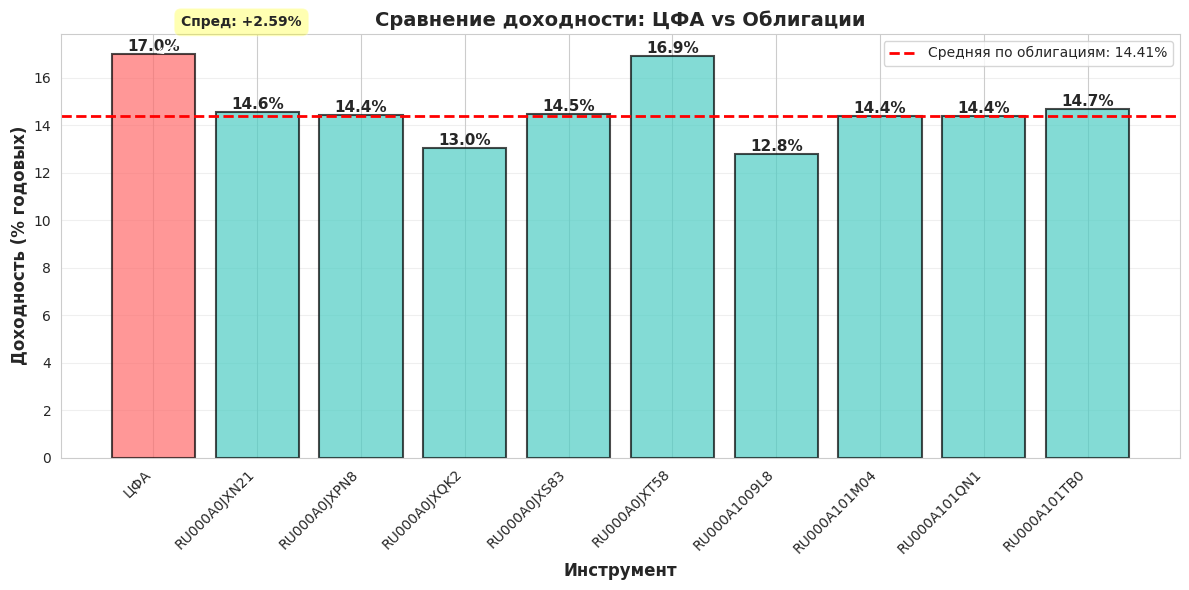


📊 ВЫВОД:
ЦФА предлагает доходность ВЫШЕ средней по облигациям на 2.59%


In [44]:
# Визуализация сравнения доходности
fig, ax = plt.subplots(figsize=(12, 6))

# Подготовка данных
instruments = ['ЦФА'] + bonds_analysis['secid'].tolist()
yields = [dfa_summary['yield_metrics']['nominal_yield_pct']] + bonds_analysis['ytm_primary'].tolist()
colors = ['#FF6B6B'] + ['#4ECDC4'] * len(bonds_analysis)

# Создание bar chart
bars = ax.bar(range(len(instruments)), yields, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Добавление линии средней доходности облигаций
avg_bond_yield = bonds_analysis['ytm_primary'].mean()
ax.axhline(y=avg_bond_yield, color='red', linestyle='--', 
          linewidth=2, label=f'Средняя по облигациям: {avg_bond_yield:.2f}%')

# Добавление значений
for bar, yield_val in zip(bars, yields):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{yield_val:.1f}%',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Настройка графика
ax.set_xlabel('Инструмент', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (% годовых)', fontsize=12, fontweight='bold')
ax.set_title('Сравнение доходности: ЦФА vs Облигации', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(instruments)))
ax.set_xticklabels(instruments, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Добавление аннотации о спреде
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
spread = dfa_yield - avg_bond_yield
ax.annotate(f'Спред: {spread:+.2f}%',
            xy=(0, dfa_yield),
            xytext=(20, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 ВЫВОД:")
if spread > 0:
    print(f"ЦФА предлагает доходность ВЫШЕ средней по облигациям на {spread:.2f}%")
else:
    print(f"ЦФА предлагает доходность НИЖЕ средней по облигациям на {abs(spread):.2f}%")

## 📊 10. График анализа спреда

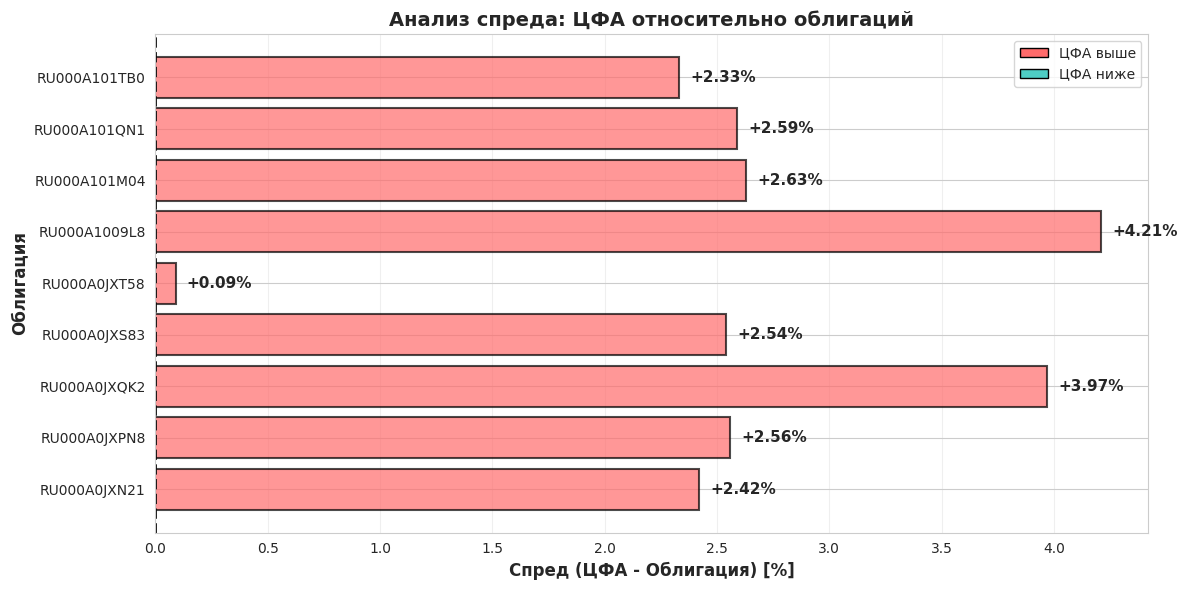


📊 АНАЛИЗ СПРЕДА:
Минимальный спред: +0.09%
Максимальный спред: +4.21%
Средний спред: +2.59%
Стд. отклонение: 1.10%


In [45]:
# Визуализация спреда
fig, ax = plt.subplots(figsize=(12, 6))

spreads = primary_comparison['absolute_spread_pct'].tolist()
bond_names = primary_comparison['bond_secid'].tolist()

# Цвета в зависимости от знака спреда
colors = ['#FF6B6B' if s > 0 else '#4ECDC4' for s in spreads]

# Горизонтальный bar chart
bars = ax.barh(range(len(spreads)), spreads, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Вертикальная линия на нуле
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)

# Добавление значений
for bar, spread in zip(bars, spreads):
    width = bar.get_width()
    ax.text(width + (0.05 if width > 0 else -0.05), 
           bar.get_y() + bar.get_height()/2,
           f'{spread:+.2f}%',
           ha='left' if width > 0 else 'right', 
           va='center', fontsize=11, fontweight='bold')

# Настройка
ax.set_xlabel('Спред (ЦФА - Облигация) [%]', fontsize=12, fontweight='bold')
ax.set_ylabel('Облигация', fontsize=12, fontweight='bold')
ax.set_title('Анализ спреда: ЦФА относительно облигаций', fontsize=14, fontweight='bold')
ax.set_yticks(range(len(bond_names)))
ax.set_yticklabels(bond_names)
ax.grid(axis='x', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', edgecolor='black', label='ЦФА выше'),
                  Patch(facecolor='#4ECDC4', edgecolor='black', label='ЦФА ниже')]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 АНАЛИЗ СПРЕДА:")
print(f"Минимальный спред: {min(spreads):+.2f}%")
print(f"Максимальный спред: {max(spreads):+.2f}%")
print(f"Средний спред: {np.mean(spreads):+.2f}%")
print(f"Стд. отклонение: {np.std(spreads):.2f}%")

#### 10.1. Ликвидность и волатильность

In [46]:
os.makedirs("figures", exist_ok=True)
 
 
def estimate_bond_volatility_by_rating(rating):
    """
    Модельная волатильность:
    AAA/AA/A/BBB -> 8%
    BB/B/CCC и ниже -> 12%
    """
    if pd.isna(rating):
        return 12.0
 
    rating = str(rating).replace("+", "").replace("-", "").upper()
 
    if rating in ["AAA", "AA", "A", "BBB"]:
        return 8.0
    return 12.0
 
 
# Для ЦФА нет публичной истории вторичных торгов,
# поэтому ставим качественную оценку низкой ликвидности
DFA_LIQUIDITY_SCORE = 0.3
 
DFA_MODEL_VOLATILITY = 15.0
 
# Таблица по облигациям
liquidity_bonds = bonds_analysis[
    [
        "secid",
        "name",
        "ytm_primary",
        "liquidity_score",
        "liquidity_adjusted_yield",
        "credit_rating",
        "risk_premium",
        "sharpe_ratio"
   ]
].copy()
 
liquidity_bonds["instrument_type"] = "Облигация"
liquidity_bonds["model_volatility_pct"] = liquidity_bonds["credit_rating"].apply(
    estimate_bond_volatility_by_rating
)
 
liquidity_bonds["liquidity_discount_pct"] = (
    liquidity_bonds["ytm_primary"] - liquidity_bonds["liquidity_adjusted_yield"]
)
 
# Строка по ЦФА
liquidity_dfa = pd.DataFrame({
    "secid": [DFA_PARAMS["id"]],
    "name": ["ЦФА ООО Центр недвижимости Маяк"],
    "ytm_primary": [dfa_summary["yield_metrics"]["nominal_yield_pct"]],
    "liquidity_score": [DFA_LIQUIDITY_SCORE],
    "liquidity_adjusted_yield": [dfa_summary["yield_metrics"]["liquidity_adjusted_yield_pct"]],
    "credit_rating": ["н/д"],
    "risk_premium": [dfa_summary["risk_metrics"]["risk_premium"]],
    "sharpe_ratio": [dfa_summary["risk_metrics"]["sharpe_ratio"]],
    "instrument_type": ["ЦФА"],
    "model_volatility_pct": [DFA_MODEL_VOLATILITY],
    "liquidity_discount_pct": [np.nan]
})
 
# Общая таблица
liquidity_volatility_all = pd.concat(
    [liquidity_dfa, liquidity_bonds],
    ignore_index=True
)
 
liquidity_volatility_slide_table = liquidity_volatility_all[
    [
        "instrument_type",
        "secid",
        "name",
        "ytm_primary",
        "liquidity_score",
        "liquidity_adjusted_yield",
        "liquidity_discount_pct",
        "model_volatility_pct",
        "risk_premium",
        "sharpe_ratio",
        "credit_rating"
    ]
].round(3)
 
display(liquidity_volatility_slide_table)

,instrument_type,secid,name,ytm_primary,liquidity_score,liquidity_adjusted_yield,liquidity_discount_pct,model_volatility_pct,risk_premium,sharpe_ratio,credit_rating
0,ЦФА,A1202FB5,ЦФА ООО Центр недвижимости Маяк,17.00,0.3,17.00,NaN,15.0,5.00,0.333,н/д
1,Облигация,RU000A0JXN21,СистемБ1P6,14.58,0.7,14.43,0.15,12.0,2.58,0.215,B
2,Облигация,RU000A0JXPN8,Ростел1P2R,14.44,0.7,14.29,0.15,12.0,2.44,0.203,B
3,Облигация,RU000A0JXQK2,Роснфт1P4,13.03,0.7,12.88,0.15,12.0,1.03,0.086,B
4,Облигация,RU000A0JXS83,ЯрОбл 2017,14.46,0.7,14.31,0.15,12.0,2.46,0.205,B
5,Облигация,RU000A0JXT58,МежИнБ01P1,16.91,0.7,16.76,0.15,12.0,4.91,0.409,B
6,Облигация,RU000A1009L8,РЖД 1Р-15R,12.79,0.7,12.64,0.15,12.0,0.79,0.066,B
7,Облигация,RU000A101M04,РЖД 1Р-20R,14.37,0.7,14.22,0.15,12.0,2.37,0.197,B
8,Облигация,RU000A101QN1,ГазпромКP4,14.41,0.7,14.26,0.15,12.0,2.41,0.201,B
9,Облигация,RU000A101TB0,ВЭБ 1P-19,14.67,0.7,14.52,0.15,12.0,2.67,0.222,B


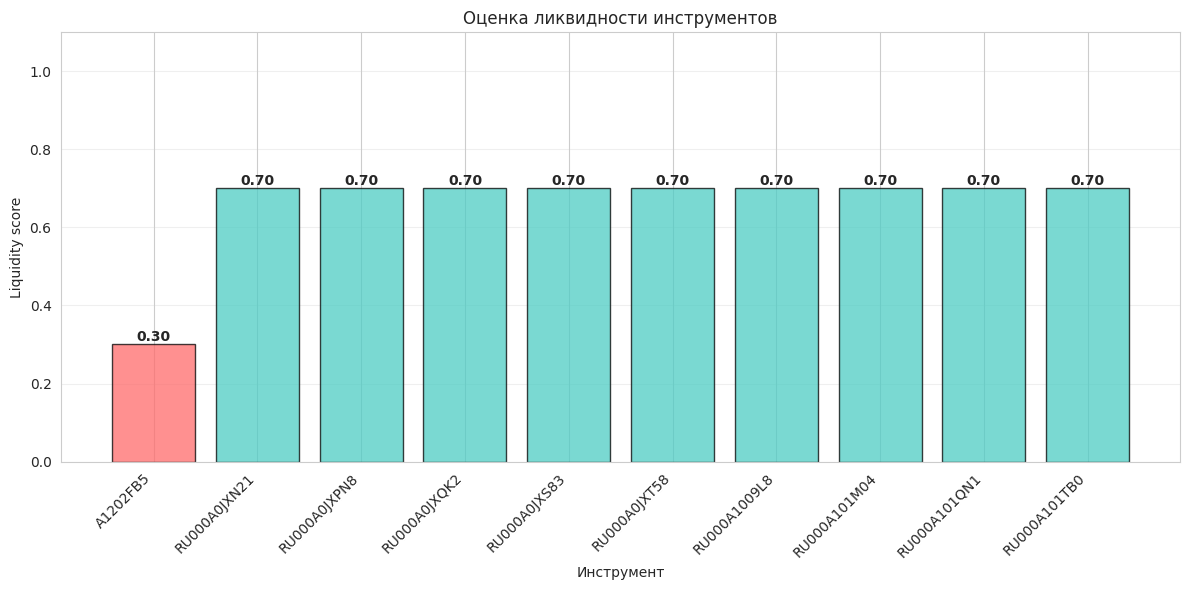

In [47]:
# График ликвидности
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = liquidity_volatility_all["instrument_type"].map({
    "ЦФА": "#FF6B6B",
    "Облигация": "#4ECDC4"
})
 
bars = ax.bar(
    liquidity_volatility_all["secid"],
    liquidity_volatility_all["liquidity_score"],
    color=colors,
    edgecolor="black",
    alpha=0.75
)
 
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )
 
ax.set_title("Оценка ликвидности инструментов")
ax.set_ylabel("Liquidity score")
ax.set_xlabel("Инструмент")
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)
 
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/liquidity_score_comparison.png", dpi=200)
plt.show()

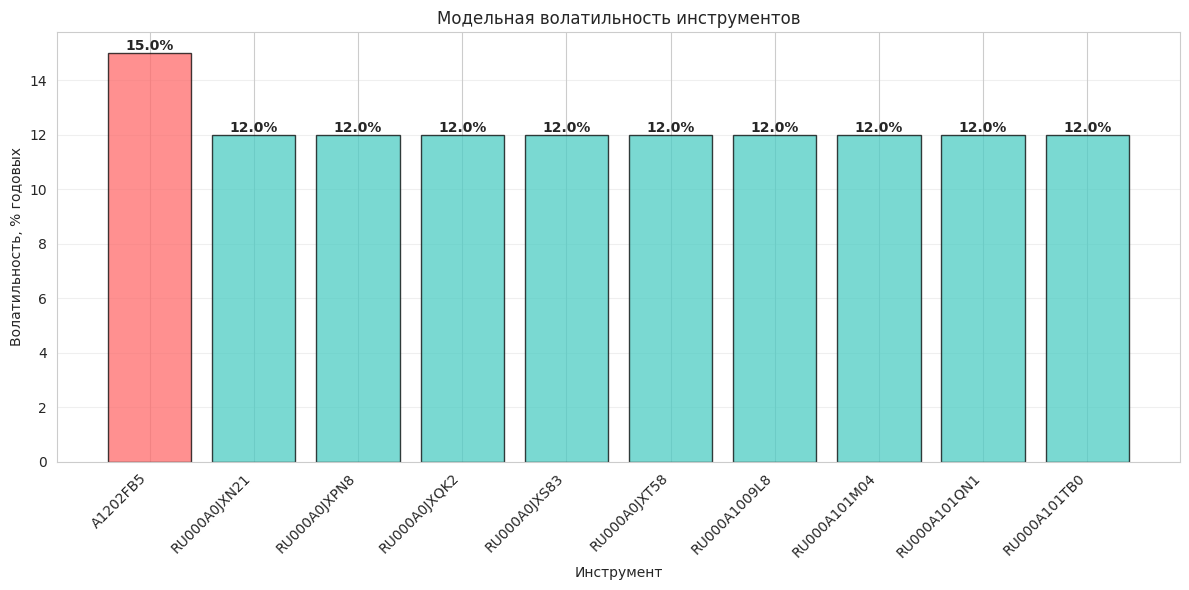

In [48]:
# График модельной волатильности
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = liquidity_volatility_all["instrument_type"].map({
    "ЦФА": "#FF6B6B",
    "Облигация": "#4ECDC4"
})
 
bars = ax.bar(
    liquidity_volatility_all["secid"],
    liquidity_volatility_all["model_volatility_pct"],
    color=colors,
    edgecolor="black",
    alpha=0.75
)
 
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )
 
ax.set_title("Модельная волатильность инструментов")
ax.set_ylabel("Волатильность, % годовых")
ax.set_xlabel("Инструмент")
ax.grid(axis="y", alpha=0.3)
 
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/model_volatility_comparison.png", dpi=200)
plt.show()

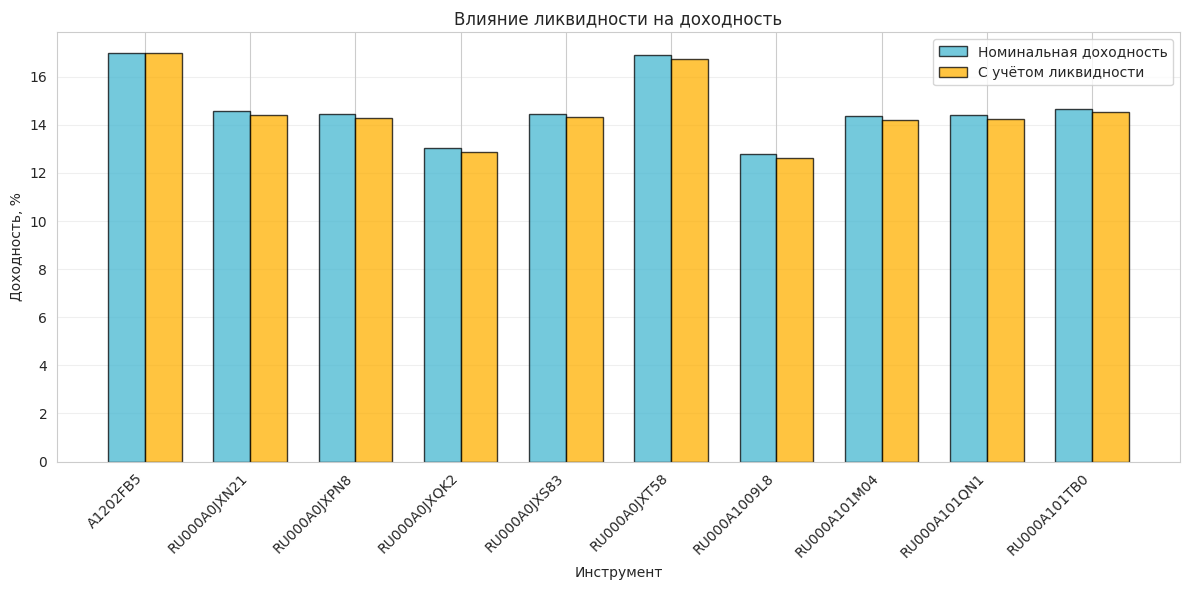

In [49]:
# График: номинальная доходность vs доходность с учётом ликвидности
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(liquidity_volatility_all))
width = 0.35
 
ax.bar(
    x - width / 2,
    liquidity_volatility_all["ytm_primary"],
    width,
    label="Номинальная доходность",
    color="#45B7D1",
    edgecolor="black",
    alpha=0.75
)
 
ax.bar(
    x + width / 2,
    liquidity_volatility_all["liquidity_adjusted_yield"],
    width,
    label="С учётом ликвидности",
    color="#FFB000",
    edgecolor="black",
    alpha=0.75
)
 
ax.set_title("Влияние ликвидности на доходность")
ax.set_ylabel("Доходность, %")
ax.set_xlabel("Инструмент")
ax.set_xticks(x)
ax.set_xticklabels(liquidity_volatility_all["secid"], rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend()
 
plt.tight_layout()
plt.savefig("figures/liquidity_adjusted_yield.png", dpi=200)
plt.show()

In [50]:
# Краткие выводы 
avg_bond_liquidity = liquidity_bonds["liquidity_score"].mean()
avg_bond_volatility = liquidity_bonds["model_volatility_pct"].mean()
 
print("ВЫВОД ПО ЛИКВИДНОСТИ И ВОЛАТИЛЬНОСТИ")
print("-" * 60)
 
print(f"Liquidity score ЦФА: {DFA_LIQUIDITY_SCORE:.2f}")
print(f"Средний liquidity score облигаций: {avg_bond_liquidity:.2f}")
 
if DFA_LIQUIDITY_SCORE < avg_bond_liquidity:
    print("ЦФА менее ликвиден, чем облигации.")
else:
    print("Ликвидность ЦФА сопоставима с облигациями.")
 
print(f"\nМодельная волатильность ЦФА: {DFA_MODEL_VOLATILITY:.2f}%")
print(f"Средняя модельная волатильность облигаций: {avg_bond_volatility:.2f}%")
 
if DFA_MODEL_VOLATILITY > avg_bond_volatility:
    print("В модели ЦФА имеет более высокий риск, чем средняя облигация.")
else:
    print("В модели риск ЦФА не выше среднего риска облигаций.")

ВЫВОД ПО ЛИКВИДНОСТИ И ВОЛАТИЛЬНОСТИ
------------------------------------------------------------
Liquidity score ЦФА: 0.30
Средний liquidity score облигаций: 0.70
ЦФА менее ликвиден, чем облигации.

Модельная волатильность ЦФА: 15.00%
Средняя модельная волатильность облигаций: 12.00%
В модели ЦФА имеет более высокий риск, чем средняя облигация.


#### 10.2. Duration и Convexity

In [51]:
def prepare_cashflows(cashflows, settlement_date):
    cf = cashflows.copy()
 
    cf["payment_date"] = pd.to_datetime(cf["payment_date"], errors="coerce")
    settlement_date = pd.to_datetime(settlement_date)
 
    cf = cf.dropna(subset=["payment_date", "amount"])
    cf = cf[cf["payment_date"] > settlement_date].copy()
 
    cf["t"] = (cf["payment_date"] - settlement_date).dt.days / 365.25
 
    return cf
 
def price_from_cashflows(cashflows, ytm, settlement_date, frequency=1):
    cf = prepare_cashflows(cashflows, settlement_date)
 
    if cf.empty:
        return np.nan
 
    return np.sum(
        cf["amount"] / (1 + ytm / frequency) ** (frequency * cf["t"])
    )
 
 
def macaulay_duration(cashflows, ytm, settlement_date, frequency=1):
    cf = prepare_cashflows(cashflows, settlement_date)
 
    if cf.empty:
        return np.nan
 
    discount_factors = (1 + ytm / frequency) ** (frequency * cf["t"])
    pv = cf["amount"] / discount_factors
    price = pv.sum()
 
    if price == 0:
        return np.nan
 
    return np.sum(cf["t"] * pv) / price
 
 
def modified_duration(cashflows, ytm, settlement_date, frequency=1):
    d_mac = macaulay_duration(cashflows, ytm, settlement_date, frequency)
 
    if pd.isna(d_mac):
        return np.nan
 
    return d_mac / (1 + ytm / frequency)
 
def numerical_duration_convexity(cashflows, ytm, settlement_date, frequency=1, shock=0.0001):
    p0 = price_from_cashflows(cashflows, ytm, settlement_date, frequency)
    p_up = price_from_cashflows(cashflows, ytm + shock, settlement_date, frequency)
    p_down = price_from_cashflows(cashflows, ytm - shock, settlement_date, frequency)
 
    if pd.isna(p0) or p0 == 0:
        return {
            "price_model": np.nan,
            "modified_duration_num": np.nan,
            "convexity_num": np.nan
        }
 
    d_mod = (p_down - p_up) / (2 * p0 * shock)
    convexity = (p_up - 2 * p0 + p_down) / (p0 * shock ** 2)
 
    return {
        "price_model": p0,
        "modified_duration_num": d_mod,
        "convexity_num": convexity
    }

In [52]:
# Денежные потоки ЦФА
dfa_cashflows = coupon_schedule[["payment_date", "coupon_amount"]].copy()
dfa_cashflows.columns = ["payment_date", "amount"]
 
# В последний платёж добавляем номинал
dfa_cashflows.loc[dfa_cashflows.index[-1], "amount"] += DFA_PARAMS["face_value"]
 
display(dfa_cashflows)

,payment_date,amount
0,2026-07-19,42.5
1,2026-10-23,42.5
2,2027-01-27,42.5
3,2027-05-03,1042.5


In [53]:
# Расчёт Duration и Convexity для ЦФА
settlement_date = DFA_PARAMS["placement_start"]
dfa_ytm = DFA_PARAMS["yield_rate"] / 100
dfa_frequency = 4
 
dfa_duration_row = {
    "instrument": "ЦФА",
    "secid": DFA_PARAMS["id"],
    "name": "ЦФА ООО Центр недвижимости Маяк",
    "ytm_pct": DFA_PARAMS["yield_rate"],
    "macaulay_duration": macaulay_duration(
        dfa_cashflows,
        dfa_ytm,
        settlement_date,
        frequency=dfa_frequency
    ),
    "modified_duration": modified_duration(
        dfa_cashflows,
        dfa_ytm,
        settlement_date,
        frequency=dfa_frequency
    ),
    **numerical_duration_convexity(
        dfa_cashflows,
        dfa_ytm,
        settlement_date,
        frequency=dfa_frequency
    )
}
 
dfa_duration_row

{'instrument': 'ЦФА',
 'secid': 'A1202FB5',
 'name': 'ЦФА ООО Центр недвижимости Маяк',
 'ytm_pct': 17.0,
 'macaulay_duration': np.float64(0.9884901526549417),
 'modified_duration': np.float64(0.9481919929543805),
 'price_model': np.float64(991.995387440442),
 'modified_duration_num': np.float64(0.9481919957950079),
 'convexity_num': np.float64(1.1586466964870277)}

In [54]:
# Денежные потоки облигаций
# берём упрощение: купон 2 раза в год
 
BOND_COUPON_FREQUENCY = 2
 
def generate_bond_cashflows_from_row(row, settlement_date, frequency=2):
    face_value = float(row.get("face_value", 1000))
    coupon_rate = float(row.get("coupon_rate", 0)) / 100
    maturity_date = pd.to_datetime(row.get("maturity_date"))
    settlement_date = pd.to_datetime(settlement_date)
 
    if pd.isna(maturity_date) or maturity_date <= settlement_date:
        return pd.DataFrame(columns=["payment_date", "amount"])
 
    coupon_amount = face_value * coupon_rate / frequency
    step_days = int(365.25 / frequency)
 
    dates = []
    current_date = maturity_date
 
    while current_date > settlement_date:
        dates.append(current_date)
        current_date = current_date - pd.Timedelta(days=step_days)
 
    dates = sorted(dates)
    amounts = [coupon_amount] * len(dates)
 
    if amounts:
        amounts[-1] += face_value
 
    return pd.DataFrame({
        "payment_date": dates,
        "amount": amounts
    })

In [55]:
# Расчёт Duration и Convexity для облигаций
duration_rows = []
 
for _, row in bonds_analysis.iterrows():
    secid = row["secid"]
 
    bond_cashflows = generate_bond_cashflows_from_row(
        row,
        settlement_date=settlement_date,
        frequency=BOND_COUPON_FREQUENCY
    )
 
    ytm = float(row["ytm_primary"]) / 100
 
    metrics = {
        "instrument": "Облигация",
        "secid": secid,
        "name": row.get("name", ""),
        "ytm_pct": row.get("ytm_primary", np.nan),
        "macaulay_duration": macaulay_duration(
            bond_cashflows,
            ytm,
            settlement_date,
            frequency=BOND_COUPON_FREQUENCY
        ),
        "modified_duration": modified_duration(
            bond_cashflows,
            ytm,
            settlement_date,
            frequency=BOND_COUPON_FREQUENCY
        ),
        **numerical_duration_convexity(
            bond_cashflows,
            ytm,
            settlement_date,
            frequency=BOND_COUPON_FREQUENCY
        )
    }
 
    duration_rows.append(metrics)
 
duration_df = pd.DataFrame(duration_rows)
 
display(duration_df)

,instrument,secid,name,ytm_pct,macaulay_duration,modified_duration,price_model,modified_duration_num,convexity_num
0,Облигация,RU000A0JXN21,СистемБ1P6,14.58,0.947296,0.882931,875.190663,0.882931,1.191036
1,Облигация,RU000A0JXPN8,Ростел1P2R,14.44,0.999316,0.932023,869.941080,0.932023,1.303299
2,Облигация,RU000A0JXQK2,Роснфт1P4,13.03,1.021218,0.958755,879.053352,0.958755,1.369269
3,Облигация,RU000A0JXS83,ЯрОбл 2017,14.46,1.015743,0.947256,325.419923,0.947256,1.338988
4,Облигация,RU000A0JXT58,МежИнБ01P1,16.91,0.878850,0.810336,867.045340,0.810336,1.030226
5,Облигация,RU000A1009L8,РЖД 1Р-15R,12.79,0.980151,0.921237,885.576948,0.921237,1.281611
6,Облигация,RU000A101M04,РЖД 1Р-20R,14.37,0.917180,0.855698,880.487860,0.855698,1.131388
7,Облигация,RU000A101QN1,ГазпромКP4,14.41,1.111567,1.036862,856.698269,1.036862,1.558670
8,Облигация,RU000A101TB0,ВЭБ 1P-19,14.67,1.155373,1.076418,849.111107,1.076418,1.660104


In [56]:
# Общая таблица Duration и Convexity
duration_all = pd.concat(
    [
        pd.DataFrame([dfa_duration_row]),
        duration_df
    ],
    ignore_index=True
)
 
duration_slide_table = duration_all[
    [
        "instrument",
        "secid",
        "name",
        "ytm_pct",
        "price_model",
        "macaulay_duration",
        "modified_duration",
        "convexity_num"
    ]
].round(4)
 
display(duration_slide_table)

,instrument,secid,name,ytm_pct,price_model,macaulay_duration,modified_duration,convexity_num
0,ЦФА,A1202FB5,ЦФА ООО Центр недвижимости Маяк,17.00,991.9954,0.9885,0.9482,1.1586
1,Облигация,RU000A0JXN21,СистемБ1P6,14.58,875.1907,0.9473,0.8829,1.1910
2,Облигация,RU000A0JXPN8,Ростел1P2R,14.44,869.9411,0.9993,0.9320,1.3033
3,Облигация,RU000A0JXQK2,Роснфт1P4,13.03,879.0534,1.0212,0.9588,1.3693
4,Облигация,RU000A0JXS83,ЯрОбл 2017,14.46,325.4199,1.0157,0.9473,1.3390
5,Облигация,RU000A0JXT58,МежИнБ01P1,16.91,867.0453,0.8789,0.8103,1.0302
6,Облигация,RU000A1009L8,РЖД 1Р-15R,12.79,885.5769,0.9802,0.9212,1.2816
7,Облигация,RU000A101M04,РЖД 1Р-20R,14.37,880.4879,0.9172,0.8557,1.1314
8,Облигация,RU000A101QN1,ГазпромКP4,14.41,856.6983,1.1116,1.0369,1.5587
9,Облигация,RU000A101TB0,ВЭБ 1P-19,14.67,849.1111,1.1554,1.0764,1.6601


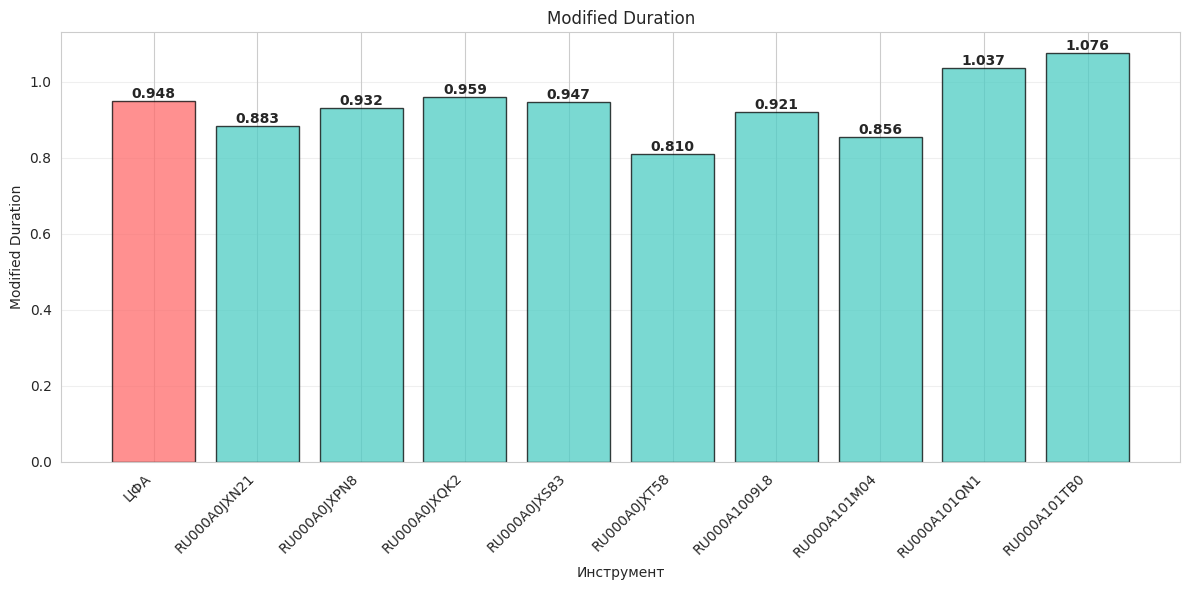

In [57]:
# График Modified Duration
labels = duration_all.apply(
    lambda row: "ЦФА" if row["instrument"] == "ЦФА" else row["secid"],
    axis=1
)
 
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = duration_all["instrument"].map({
    "ЦФА": "#FF6B6B",
    "Облигация": "#4ECDC4"
})
 
bars = ax.bar(
    labels,
    duration_all["modified_duration"],
    color=colors,
    alpha=0.75,
    edgecolor="black"
)
 
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )
 
ax.set_title("Modified Duration")
ax.set_ylabel("Modified Duration")
ax.set_xlabel("Инструмент")
ax.grid(axis="y", alpha=0.3)
 
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/modified_duration_comparison.png", dpi=200)
plt.show()

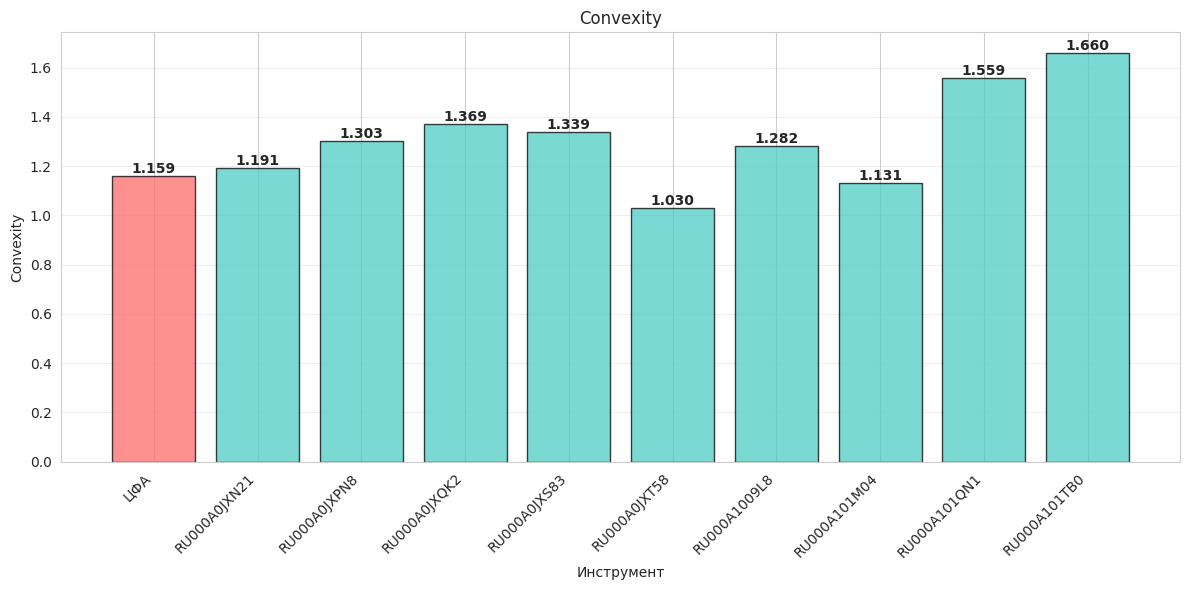

In [58]:
# График Convexity
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = duration_all["instrument"].map({
    "ЦФА": "#FF6B6B",
    "Облигация": "#4ECDC4"
})
 
bars = ax.bar(
    labels,
    duration_all["convexity_num"],
    color=colors,
    alpha=0.75,
    edgecolor="black"
)
 
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )
 
ax.set_title("Convexity")
ax.set_ylabel("Convexity")
ax.set_xlabel("Инструмент")
ax.grid(axis="y", alpha=0.3)
 
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/convexity_comparison.png", dpi=200)
plt.show()

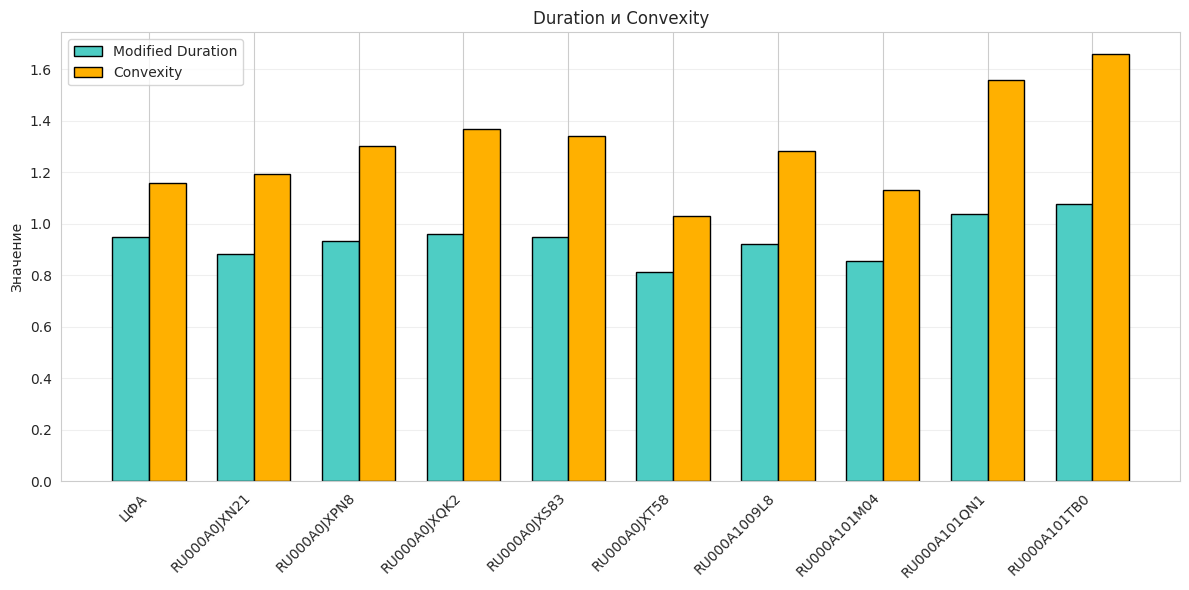

In [59]:
# Общий график Duration и Convexity
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(duration_all))
width = 0.35
 
ax.bar(
    x - width / 2,
    duration_all["modified_duration"],
    width,
    label="Modified Duration",
    color="#4ECDC4",
    edgecolor="black"
)
 
ax.bar(
    x + width / 2,
    duration_all["convexity_num"],
    width,
    label="Convexity",
    color="#FFB000",
    edgecolor="black"
)
 
ax.set_title("Duration и Convexity")
ax.set_ylabel("Значение")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend()
 
plt.tight_layout()
plt.savefig("figures/duration_convexity_comparison.png", dpi=200)
plt.show()

In [60]:
# Краткие выводы
dfa_mod_duration = duration_all.loc[
    duration_all["instrument"] == "ЦФА",
    "modified_duration"
].iloc[0]
 
avg_bond_mod_duration = duration_all.loc[
    duration_all["instrument"] == "Облигация",
    "modified_duration"
].mean()
 
print("ВЫВОД ПО DURATION И CONVEXITY")
print("-" * 60)
 
print(f"Modified Duration ЦФА: {dfa_mod_duration:.3f}")
print(f"Средняя Modified Duration облигаций: {avg_bond_mod_duration:.3f}")
 
if dfa_mod_duration > avg_bond_mod_duration:
    print("ЦФА более чувствителен к изменению доходности, чем средняя облигация.")
elif dfa_mod_duration < avg_bond_mod_duration:
    print("Облигации в среднем более чувствительны к изменению доходности, чем ЦФА.")
else:
    print("Процентный риск ЦФА и облигаций примерно сопоставим.")
 
print("Для облигаций расчёт приближённый, так как используется упрощённый график купонов.")
 

ВЫВОД ПО DURATION И CONVEXITY
------------------------------------------------------------
Modified Duration ЦФА: 0.948
Средняя Modified Duration облигаций: 0.936
ЦФА более чувствителен к изменению доходности, чем средняя облигация.
Для облигаций расчёт приближённый, так как используется упрощённый график купонов.


## ⚡ 11. Профиль риск-доходность

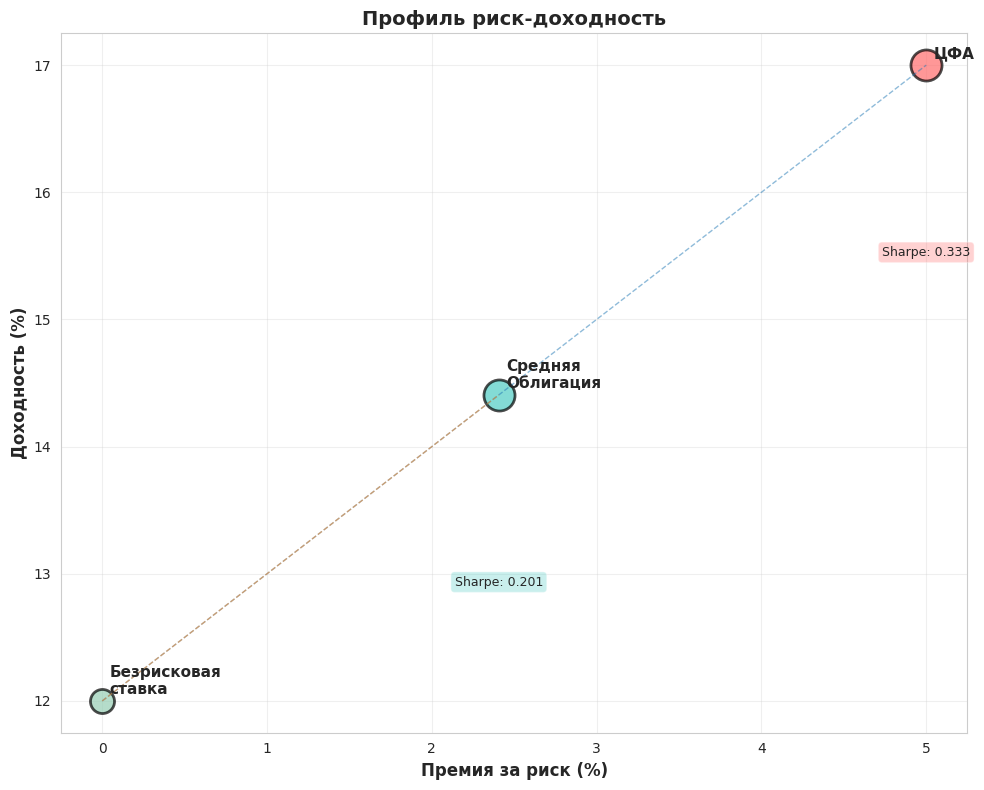


⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:

ЦФА:
  Доходность: 17.00%
  Риск: 5.00%
  Sharpe: 0.333

Облигации (средние):
  Доходность: 14.41%
  Риск: 2.41%
  Sharpe: 0.201

✅ ЦФА показывает лучшую эффективность по Sharpe


In [61]:
# Получение данных риск-доходность
risk_return_profile = comparator.analyze_risk_return_profile()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))

# Данные
instruments = ['ЦФА', 'Средняя\nОблигация', 'Безрисковая\nставка']
returns = [
    dfa_summary['yield_metrics']['nominal_yield_pct'],
    bonds_summary['yield_stats']['mean_ytm'],
    ANALYSIS_CONFIG['risk_free_rate']
]
risks = [
    dfa_summary['risk_metrics']['risk_premium'],
    bonds_summary['risk_stats']['mean_risk_premium'],
    0
]
sizes = [500, 500, 300]
colors = ['#FF6B6B', '#4ECDC4', '#96CEB4']

# Scatter plot
for i, (instrument, ret, risk, size, color) in enumerate(zip(instruments, returns, risks, sizes, colors)):
    ax.scatter(risk, ret, s=size, alpha=0.7, color=color, 
               edgecolors='black', linewidth=2)
    ax.annotate(instrument, (risk, ret),
               xytext=(5, 5), textcoords='offset points',
               fontsize=11, fontweight='bold')

# Добавление линий от безрисковой ставки
for i in range(2):
    ax.plot([0, risks[i]], [ANALYSIS_CONFIG['risk_free_rate'], returns[i]],
            '--', alpha=0.5, linewidth=1)

# Настройка
ax.set_xlabel('Премия за риск (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (%)', fontsize=12, fontweight='bold')
ax.set_title('Профиль риск-доходность', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавление аннотаций Sharpe ratio
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

ax.text(risks[0], returns[0] - 1.5, f"Sharpe: {dfa_sharpe:.3f}",
       ha='center', fontsize=9, 
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#FF6B6B', alpha=0.3))
ax.text(risks[1], returns[1] - 1.5, f"Sharpe: {bond_sharpe:.3f}",
       ha='center', fontsize=9,
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#4ECDC4', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:")
print(f"\nЦФА:")
print(f"  Доходность: {returns[0]:.2f}%")
print(f"  Риск: {risks[0]:.2f}%")
print(f"  Sharpe: {dfa_sharpe:.3f}")

print(f"\nОблигации (средние):")
print(f"  Доходность: {returns[1]:.2f}%")
print(f"  Риск: {risks[1]:.2f}%")
print(f"  Sharpe: {bond_sharpe:.3f}")

if dfa_sharpe > bond_sharpe:
    print("\n✅ ЦФА показывает лучшую эффективность по Sharpe")
else:
    print("\n✅ Облигации показывают лучшую эффективность по Sharpe")

## 🔍 12. Декомпозиция спреда


🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:
🔴 Liquidity Component: +2.74%
🟢 Credit Component: +0.00%
🔴 Technology Component: +0.50%
🔴 Regulatory Component: +0.30%

📊 Необъясненный остаток: -0.95%


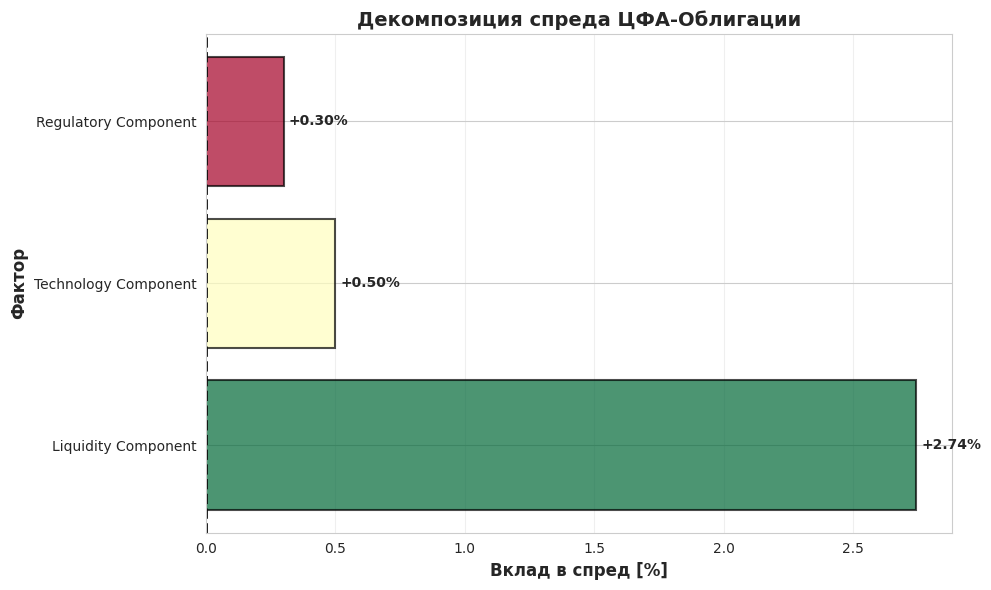

In [62]:
# Анализ факторов спреда
spread_drivers = comparator.identify_spread_drivers()

print("\n🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:")
print("=" * 60)

for driver, value in spread_drivers.items():
    if driver not in ['total_spread', 'unexplained']:
        icon = "🔴" if value > 0 else "🟢"
        print(f"{icon} {driver.replace('_', ' ').title()}: {value:+.2f}%")

print(f"\n📊 Необъясненный остаток: {spread_drivers['unexplained']:+.2f}%")
print("=" * 60)

# Визуализация декомпозиции
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных (исключая total_spread и unexplained)
plot_drivers = {k: v for k, v in spread_drivers.items() 
                if k not in ['total_spread', 'unexplained'] and v != 0}

driver_names = [name.replace('_', ' ').title() for name in plot_drivers.keys()]
driver_values = list(plot_drivers.values())

if len(driver_values) > 0:
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(driver_values)))
    
    bars = ax.barh(range(len(driver_values)), driver_values,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Вертикальная линия
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    
    # Значения
    for bar, value in zip(bars, driver_values):
        width = bar.get_width()
        ax.text(width + (0.02 if width > 0 else -0.02),
               bar.get_y() + bar.get_height()/2,
               f'{value:+.2f}%',
               ha='left' if width > 0 else 'right',
               va='center', fontsize=10, fontweight='bold')
    
    # Настройка
    ax.set_xlabel('Вклад в спред [%]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Фактор', fontsize=12, fontweight='bold')
    ax.set_title('Декомпозиция спреда ЦФА-Облигации', fontsize=14, fontweight='bold')
    ax.set_yticks(range(len(driver_names)))
    ax.set_yticklabels(driver_names)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 🎯 13. Инвестиционные рекомендации

In [63]:
# Генерация рекомендаций
recommendation = comparator.generate_investment_recommendation()

print("\n" + "=" * 70)
print("🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ")
print("=" * 70)

print(f"\n📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: {recommendation['overall_recommendation'].upper()}")
print(f"\nОбоснование: {recommendation['reasoning']}")

print(f"\n📈 КЛЮЧЕВЫЕ ФАКТОРЫ:")
key_factors = recommendation['key_factors']
print(f"  • Преимущество в доходности: {key_factors['yield_advantage']:+.2f}%")
print(f"  • Преимущество в Sharpe: {key_factors['sharpe_advantage']:+.3f}")
print(f"  • Дисконт за ликвидность: {key_factors['liquidity_disadvantage']:+.2f}%")

print(f"\n👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:")
for profile, advice in recommendation['investor_suggestions'].items():
    print(f"\n  {profile.upper()} ИНВЕСТОР:")
    print(f"    Выбор: {advice['preferred']}")
    print(f"    Обоснование: {advice['reason']}")

print("\n" + "=" * 70)


🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ

📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: DFA

Обоснование: DFA offers better risk-adjusted returns

📈 КЛЮЧЕВЫЕ ФАКТОРЫ:
  • Преимущество в доходности: +2.59%
  • Преимущество в Sharpe: +0.133
  • Дисконт за ликвидность: +2.74%

👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:

  CONSERVATIVE ИНВЕСТОР:
    Выбор: Bonds
    Обоснование: Higher liquidity, established market, lower regulatory risk

  BALANCED ИНВЕСТОР:
    Выбор: DFA
    Обоснование: DFA offers better risk-adjusted returns

  AGGRESSIVE ИНВЕСТОР:
    Выбор: DFA
    Обоснование: Higher yield potential, diversification benefit



## 📊 14. Сводная таблица сравнения

In [64]:
# Создание сводной таблицы
summary_data = {
    'Показатель': [
        'Доходность номинальная (%)',
        'Доходность после налога (%)',
        'Срок обращения (мес)',
        'Премия за риск (%)',
        'Sharpe Ratio',
        'Мин. сумма инвестиции (₽)',
        'Ликвидность',
        'Риски'
    ],
    'ЦФА': [
        f"{dfa_summary['yield_metrics']['nominal_yield_pct']:.2f}",
        f"{dfa_summary['yield_metrics']['after_tax_yield_pct']:.2f}",
        f"{dfa_summary['time_metrics']['years_to_maturity']*12:.0f}",
        f"{dfa_summary['risk_metrics']['risk_premium']:.2f}",
        f"{dfa_summary['risk_metrics']['sharpe_ratio']:.3f}",
        f"{DFA_PARAMS['min_investment']:,.0f}",
        'Низкая',
        'Высокие (технология, регуляция)'
    ],
    'Облигации (средние)': [
        f"{bonds_summary['yield_stats']['mean_ytm']:.2f}",
        f"{bonds_summary['after_tax_stats']['mean_after_tax']:.2f}",
        '12',
        f"{bonds_summary['risk_stats']['mean_risk_premium']:.2f}",
        f"{bonds_summary['risk_stats']['mean_sharpe']:.3f}",
        '1,000 - 100,000',
        'Высокая',
        'Средние (кредитный, процентный)'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)


📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ
                 Показатель                             ЦФА             Облигации (средние)
 Доходность номинальная (%)                           17.00                           14.41
Доходность после налога (%)                           14.79                            0.00
       Срок обращения (мес)                              13                              12
         Премия за риск (%)                            5.00                            2.41
               Sharpe Ratio                           0.333                           0.201
  Мин. сумма инвестиции (₽)                           1,000                 1,000 - 100,000
                Ликвидность                          Низкая                         Высокая
                      Риски Высокие (технология, регуляция) Средние (кредитный, процентный)


## ✅ 15. Заключение и выводы

In [65]:
print("\n" + "=" * 70)
print("✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ")
print("=" * 70)

# Ключевые метрики
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
avg_bond_yield = bonds_summary['yield_stats']['mean_ytm']
spread = dfa_yield - avg_bond_yield
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
avg_bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

print("\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 50)

print(f"\n1. ДОХОДНОСТЬ:")
if abs(spread) < 0.5:
    print(f"   ✅ Спред минимальный ({spread:+.2f}%) - доходности сопоставимы")
elif spread > 0:
    print(f"   📈 ЦФА превосходит облигации на {spread:.2f}%")
else:
    print(f"   📉 Облигации превосходят ЦФА на {abs(spread):.2f}%")

print(f"\n2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):")
if dfa_sharpe > avg_bond_sharpe:
    print(f"   ✅ ЦФА: {dfa_sharpe:.3f} > Облигации: {avg_bond_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")
else:
    print(f"   ✅ Облигации: {avg_bond_sharpe:.3f} > ЦФА: {dfa_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")

print(f"\n3. ЛИКВИДНОСТЬ:")
print(f"   ✅ Облигации: Высокая ликвидность (биржевой рынок)")
print(f"   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)")
print(f"   💡 Премия за ликвидность: {ANALYSIS_CONFIG['liquidity_discount_bonds']:.1f}%")

print(f"\n4. РИСКИ:")
print(f"   Общие: кредитный риск, процентный риск")
print(f"   ЦФА-специфичные: технологические, регуляторные")
print(f"   Облигации: рыночные, инфляционные")

print(f"\n" + "=" * 70)
print("🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:")
print("=" * 70)

print("\n✅ Для КОНСЕРВАТИВНЫХ инвесторов:")
print("   → Выбирайте ОБЛИГАЦИИ")
print("   ✓ Высокая ликвидность")
print("   ✓ Прозрачное регулирование")
print("   ✓ Биржевая торговля")

print("\n✅ Для АГРЕССИВНЫХ инвесторов:")
print("   → Рассмотрите ЦФА")
print("   ✓ Потенциально более высокая доходность")
print("   ✓ Диверсификация портфеля")
print("   ✓ Доступ к инновационным инструментам")

print("\n✅ Для СБАЛАНСИРОВАННЫХ инвесторов:")
print("   → Диверсификация: ЦФА + Облигации")
print("   ✓ Баланс риска и доходности")
print("   ✓ Различные профильные характеристики")

print("\n" + "=" * 70)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("=" * 70)


✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ

📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
--------------------------------------------------

1. ДОХОДНОСТЬ:
   📈 ЦФА превосходит облигации на 2.59%

2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):
   ✅ ЦФА: 0.333 > Облигации: 0.201
   💡 Лучший риск-скорректированный доход

3. ЛИКВИДНОСТЬ:
   ✅ Облигации: Высокая ликвидность (биржевой рынок)
   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)
   💡 Премия за ликвидность: 0.5%

4. РИСКИ:
   Общие: кредитный риск, процентный риск
   ЦФА-специфичные: технологические, регуляторные
   Облигации: рыночные, инфляционные

🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:

✅ Для КОНСЕРВАТИВНЫХ инвесторов:
   → Выбирайте ОБЛИГАЦИИ
   ✓ Высокая ликвидность
   ✓ Прозрачное регулирование
   ✓ Биржевая торговля

✅ Для АГРЕССИВНЫХ инвесторов:
   → Рассмотрите ЦФА
   ✓ Потенциально более высокая доходность
   ✓ Диверсификация портфеля
   ✓ Доступ к инновационным инструментам

✅ Для СБАЛАНСИРОВАННЫХ инвесторов:
   → Диверсификация: ЦФА + Облигации
   ✓ Баланс риска и доходности
   ✓ Разли